---
title: Motion Estimation
sidebarTitle: Motion Estimation
description: Motion estimation from intuition to implementation using synthetic image pairs, patch matching, sparse motion fields, and failure analysis.
---


# Motion estimation

Motion estimation asks a simple question: if something moves between two frames, can we recover **where it went**?

In this notebook we will:

- build intuition for motion in image coordinates,
- recover motion with a readable patch-matching baseline,
- estimate a sparse motion field on synthetic data with known ground truth,
- quantify accuracy with endpoint error and match ratios,
- study how patch size, search radius, and noise change the results,
- and inspect failure modes that motivate more advanced optical-flow methods.

The goal is not to be fancy. The goal is to make the core idea visible and trustworthy.


## Intuition

Between two video frames, a moving object often keeps a similar local appearance.
That means a small patch around a point in Frame 1 may reappear a few pixels away in Frame 2.

We will use the image-coordinate convention common in vision:

- $x$ increases to the **right**,
- $y$ increases **downward**,
- a motion vector is written as $(dx, dy)$.

So $(dx=5, dy=-4)$ means "move 5 pixels right and 4 pixels up."

![Frame pair overview](assets/frame-pair.svg)

The SVG above is just a clean overview diagram. The next executable figure generates the actual synthetic frames and overlays the tracked patch directly from code.


## Imports and plotting style

The notebook uses only `numpy` and `matplotlib`. A fixed random seed keeps the synthetic examples reproducible.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fbfdff",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.titlesize": 15,
    }
)

rng = np.random.default_rng(7)


Matplotlib is building the font cache; this may take a moment.


## Synthetic example setup

We start with clean synthetic frames because the true motion is known exactly.
That lets us debug the estimator before dealing with real video.

The scene uses a few textured geometric shapes so patch matching has enough visual structure to lock onto.


The helper below builds a frame, applies an integer translation, and optionally adds Gaussian noise. Running the cell also draws the two frames side by side.


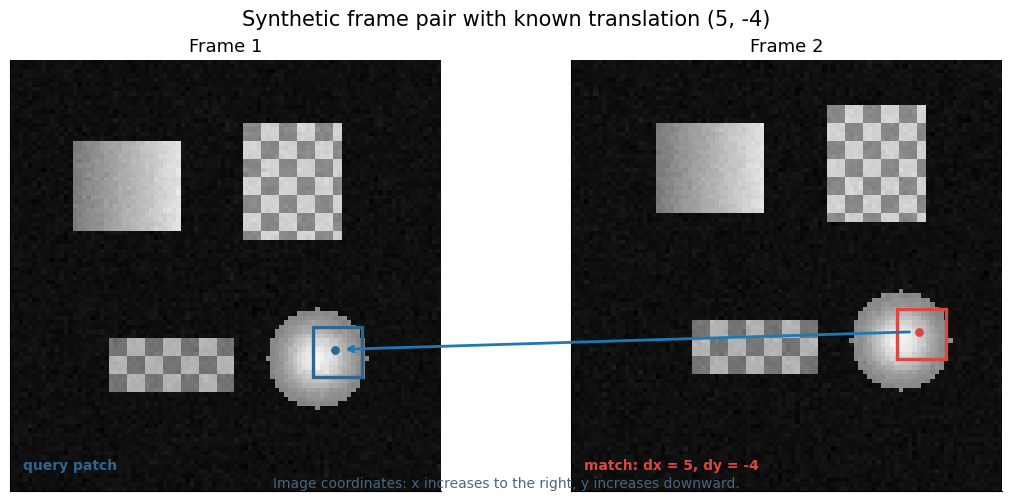

In [2]:
def normalize_image(img):
    return np.clip(img, 0.0, 1.0)


def add_rectangle(img, x0, y0, w, h, base=0.75, texture="flat"):
    yy, xx = np.mgrid[y0 : y0 + h, x0 : x0 + w]
    patch = np.full((h, w), base, dtype=float)
    if texture == "gradient":
        patch *= 0.55 + 0.45 * (xx - x0) / max(w - 1, 1)
    elif texture == "checker":
        patch *= 0.65 + 0.35 * (((xx - x0) // 4 + (yy - y0) // 4) % 2)
    img[y0 : y0 + h, x0 : x0 + w] = np.maximum(img[y0 : y0 + h, x0 : x0 + w], patch)


def add_disk(img, cx, cy, radius, base=0.82):
    yy, xx = np.mgrid[: img.shape[0], : img.shape[1]]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    mask = dist <= radius
    ripple = 0.78 + 0.22 * np.cos(dist[mask] / max(radius, 1) * np.pi)
    img[mask] = np.maximum(img[mask], base * ripple)


def shift_image_integer(img, dx, dy, fill_value=0.06):
    shifted = np.full_like(img, fill_value)
    h, w = img.shape

    src_x0 = max(0, -dx)
    src_x1 = min(w, w - dx)
    src_y0 = max(0, -dy)
    src_y1 = min(h, h - dy)

    dst_x0 = max(0, dx)
    dst_x1 = dst_x0 + (src_x1 - src_x0)
    dst_y0 = max(0, dy)
    dst_y1 = dst_y0 + (src_y1 - src_y0)

    if src_x1 > src_x0 and src_y1 > src_y0:
        shifted[dst_y0:dst_y1, dst_x0:dst_x1] = img[src_y0:src_y1, src_x0:src_x1]
    return shifted


def make_synthetic_pair(dx=5, dy=-4, noise_std=0.0, size=96, seed=None):
    frame1 = np.full((size, size), 0.06, dtype=float)
    add_rectangle(frame1, 14, 18, 24, 20, base=0.88, texture="gradient")
    add_rectangle(frame1, 52, 14, 22, 26, base=0.82, texture="checker")
    add_rectangle(frame1, 22, 62, 28, 12, base=0.70, texture="checker")
    add_disk(frame1, 68, 66, 11, base=0.95)

    frame2 = shift_image_integer(frame1, dx=dx, dy=dy, fill_value=0.06)

    local_rng = np.random.default_rng(seed) if seed is not None else rng
    if noise_std > 0:
        frame1 = normalize_image(frame1 + local_rng.normal(0.0, noise_std, frame1.shape))
        frame2 = normalize_image(frame2 + local_rng.normal(0.0, noise_std, frame2.shape))

    return frame1, frame2, np.array([dx, dy], dtype=int)


def show_frame_pair(frame1, frame2, gt_motion, point_xy=None, patch_size=None):
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.9), constrained_layout=True)
    motion_tuple = tuple(map(int, gt_motion))

    for ax, image, title in zip(axes, [frame1, frame2], ["Frame 1", "Frame 2"]):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1, origin="upper")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    if point_xy is not None and patch_size is not None:
        radius = patch_size // 2
        match_xy = (point_xy[0] + int(gt_motion[0]), point_xy[1] + int(gt_motion[1]))
        query_color = "#2f6690"
        match_color = "#d94841"

        axes[0].add_patch(
            Rectangle((point_xy[0] - radius, point_xy[1] - radius), patch_size, patch_size,
                      edgecolor=query_color, facecolor="none", linewidth=2.4)
        )
        axes[1].add_patch(
            Rectangle((match_xy[0] - radius, match_xy[1] - radius), patch_size, patch_size,
                      edgecolor=match_color, facecolor="none", linewidth=2.4)
        )
        axes[0].scatter(*point_xy, s=28, color=query_color, zorder=4)
        axes[1].scatter(*match_xy, s=28, color=match_color, zorder=4)
        axes[0].text(0.03, 0.05, "query patch", transform=axes[0].transAxes,
                     color=query_color, fontsize=10, weight="bold")
        axes[1].text(0.03, 0.05, f"match: dx = {motion_tuple[0]}, dy = {motion_tuple[1]}",
                     transform=axes[1].transAxes, color=match_color, fontsize=10, weight="bold")

        connector = ConnectionPatch(
            xyA=match_xy,
            coordsA="data",
            axesA=axes[1],
            xyB=point_xy,
            coordsB="data",
            axesB=axes[0],
            arrowstyle="->",
            linewidth=2.0,
            color="#1f77b4",
            shrinkA=7,
            shrinkB=7,
        )
        fig.add_artist(connector)

    fig.suptitle(f"Synthetic frame pair with known translation {motion_tuple}")
    fig.text(0.5, 0.01, "Image coordinates: x increases to the right, y increases downward.",
             ha="center", va="bottom", fontsize=10, color="#486581")
    plt.show()


demo_point_xy = (72, 64)
demo_patch_size = 11
frame1, frame2, gt_motion = make_synthetic_pair(dx=5, dy=-4, noise_std=0.015, seed=7)
show_frame_pair(frame1, frame2, gt_motion, point_xy=demo_point_xy, patch_size=demo_patch_size)


## Patch matching / local search

The baseline method is deliberately simple:

1. extract an odd-sized patch around a point in Frame 1,
2. search a square window around the same location in Frame 2,
3. score each candidate with SSD (sum of squared differences),
4. keep the displacement with the lowest score.

This is easy to read and easy to reason about, which makes it a good teaching baseline.

![Patch matching diagram](assets/patch-matching.svg)

The SVG is a conceptual sketch. The executable figure below shows the real query patch, the actual search window, the chosen match, and the SSD heatmap produced by the current code.


The next cell defines reusable helpers for patch extraction, SSD scoring, exhaustive local search, and patch-match visualization.


In [3]:
def extract_patch(image, center_xy, patch_size):
    radius = patch_size // 2
    x, y = map(int, center_xy)
    if x - radius < 0 or y - radius < 0:
        return None
    if x + radius >= image.shape[1] or y + radius >= image.shape[0]:
        return None
    return image[y - radius : y + radius + 1, x - radius : x + radius + 1]


def ssd_cost(template, candidate):
    diff = template - candidate
    return float(np.sum(diff * diff))


def filter_trackable_points(points, image_shape, patch_size, search_radius):
    radius = patch_size // 2 + search_radius
    height, width = image_shape
    valid_points = []
    for x, y in points:
        if radius <= x < width - radius and radius <= y < height - radius:
            valid_points.append((x, y))
    return valid_points


def estimate_patch_motion(frame1, frame2, point_xy, patch_size=11, search_radius=8):
    template = extract_patch(frame1, point_xy, patch_size)
    if template is None:
        raise ValueError("Source patch falls outside the image.")

    costs = np.full((2 * search_radius + 1, 2 * search_radius + 1), np.inf)
    best = {"cost": np.inf, "dx": 0, "dy": 0, "match_patch": None, "best_point": point_xy}

    for row, dy in enumerate(range(-search_radius, search_radius + 1)):
        for col, dx in enumerate(range(-search_radius, search_radius + 1)):
            candidate_point = (point_xy[0] + dx, point_xy[1] + dy)
            candidate = extract_patch(frame2, candidate_point, patch_size)
            if candidate is None:
                continue
            cost = ssd_cost(template, candidate)
            costs[row, col] = cost
            if cost < best["cost"]:
                best = {
                    "cost": cost,
                    "dx": dx,
                    "dy": dy,
                    "match_patch": candidate,
                    "best_point": candidate_point,
                }

    best["template_patch"] = template
    best["cost_map"] = costs
    return best


def draw_patch_matching_demo(frame1, frame2, point_xy, match_result, patch_size, search_radius):
    radius = patch_size // 2
    x, y = point_xy
    best_x, best_y = match_result["best_point"]
    best_dx, best_dy = match_result["dx"], match_result["dy"]
    min_col = best_dx + search_radius
    min_row = best_dy + search_radius

    fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.5), constrained_layout=True)

    axes[0].imshow(frame1, cmap="gray", vmin=0, vmax=1, origin="upper")
    axes[0].add_patch(Rectangle((x - radius, y - radius), patch_size, patch_size,
                                edgecolor="#2f6690", facecolor="none", linewidth=2.4))
    axes[0].scatter(x, y, s=24, color="#2f6690", zorder=4)
    axes[0].text(0.03, 0.05, "query patch", transform=axes[0].transAxes,
                 color="#2f6690", fontsize=10, weight="bold")
    axes[0].set_title("Frame 1")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(frame2, cmap="gray", vmin=0, vmax=1, origin="upper")
    axes[1].add_patch(Rectangle((x - search_radius - radius, y - search_radius - radius),
                                2 * search_radius + patch_size,
                                2 * search_radius + patch_size,
                                edgecolor="#7c3aed", facecolor="none", linewidth=2.2, linestyle="--"))
    axes[1].add_patch(Rectangle((best_x - radius, best_y - radius), patch_size, patch_size,
                                edgecolor="#d94841", facecolor="none", linewidth=2.4))
    axes[1].annotate("", xy=(best_x, best_y), xytext=(x, y),
                     arrowprops=dict(arrowstyle="->", lw=2.0, color="#1f77b4"))
    axes[1].text(0.03, 0.05, f"best shift = ({best_dx}, {best_dy})", transform=axes[1].transAxes,
                 color="#d94841", fontsize=10, weight="bold")
    axes[1].set_title("Frame 2")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    im = axes[2].imshow(match_result["cost_map"], cmap="magma_r", origin="lower")
    axes[2].scatter(min_col, min_row, s=70, color="white", edgecolors="#1f2933", linewidths=1.0, zorder=4)
    axes[2].set_title("SSD cost heatmap")
    axes[2].set_xlabel("dx")
    axes[2].set_ylabel("dy")
    tick_positions = np.arange(0, 2 * search_radius + 1, 2)
    tick_labels = np.arange(-search_radius, search_radius + 1, 2)
    axes[2].set_xticks(tick_positions, tick_labels)
    axes[2].set_yticks(tick_positions, tick_labels)
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_label("SSD cost")
    plt.show()


def draw_patch_pair(match_result):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.4), constrained_layout=True)
    axes[0].imshow(match_result["template_patch"], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Source patch")
    axes[1].imshow(match_result["match_patch"], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Matched patch")
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()


## Single-point motion estimation demo

We first track one carefully chosen point so every part of the process is visible.
The figure highlights the source patch, the search window, the matched patch, and the resulting motion vector.


Estimated motion at (72, 64): (dx=5, dy=-4)
Ground truth motion: (5, -4)
Best SSD cost: 0.0436


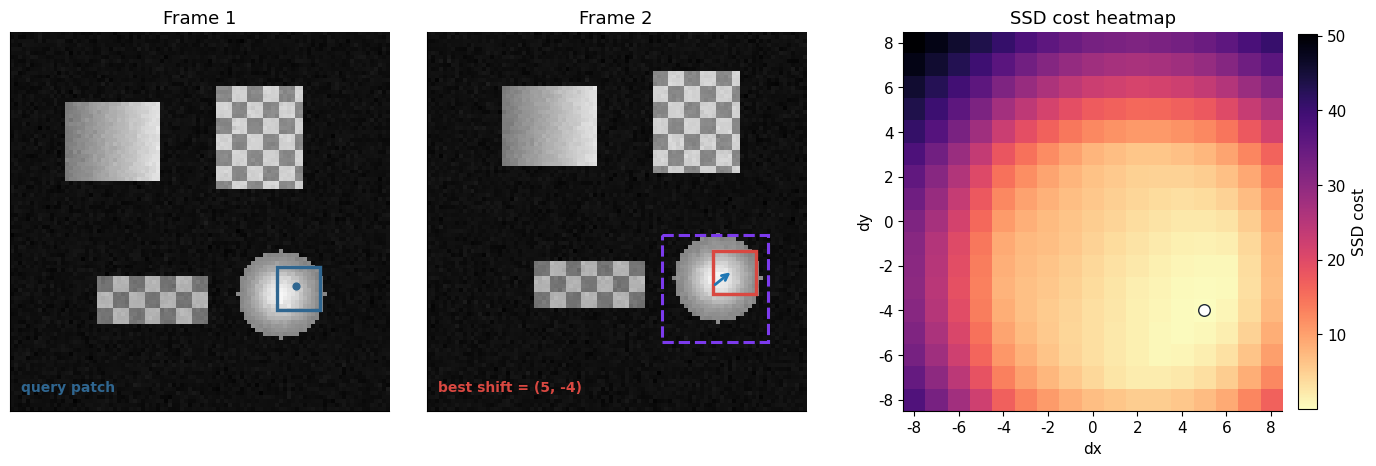

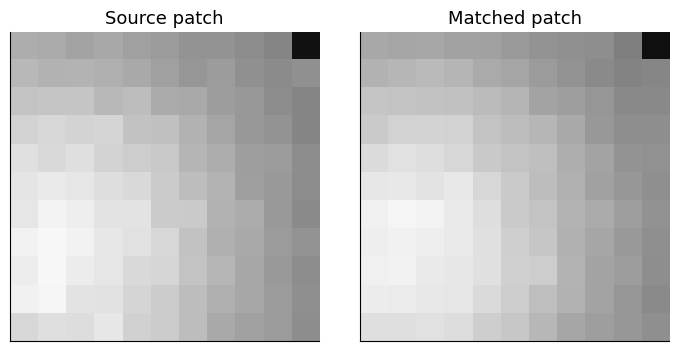

In [4]:
point_xy = demo_point_xy
patch_size = demo_patch_size
search_radius = 8

match_result = estimate_patch_motion(frame1, frame2, point_xy, patch_size=patch_size, search_radius=search_radius)
print(f"Estimated motion at {point_xy}: (dx={match_result['dx']}, dy={match_result['dy']})")
print(f"Ground truth motion: {tuple(map(int, gt_motion))}")
print(f"Best SSD cost: {match_result['cost']:.4f}")

draw_patch_matching_demo(frame1, frame2, point_xy, match_result, patch_size, search_radius)
draw_patch_pair(match_result)


## Sparse motion field estimation

One point is useful for intuition, but a motion field becomes more interesting when we estimate many arrows.
We will sample textured points on a grid and run the same local matcher at each one.

![Sparse motion field](assets/sparse-field.svg)

The overview diagram is followed by a code-generated quiver plot. For readability, the display shows a subset of arrows, while the summary metrics still use every valid sampled point.


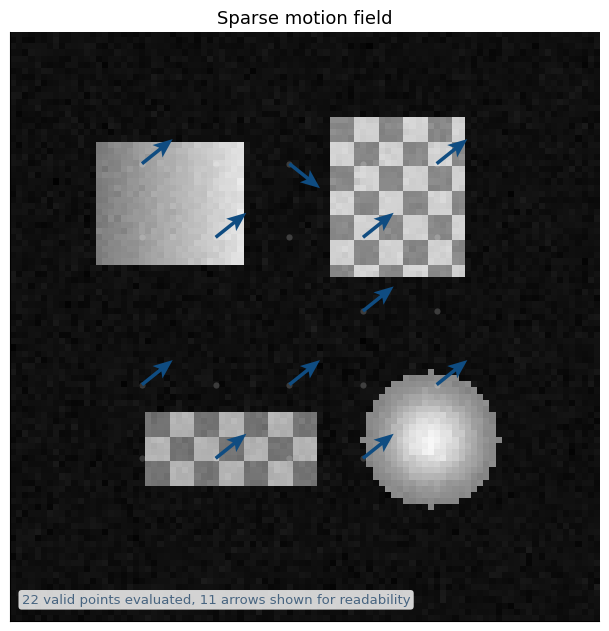

In [5]:
def sample_textured_points(frame, patch_size, stride=12, threshold=0.18):
    radius = patch_size // 2
    points = []
    for y in range(radius + 2, frame.shape[0] - radius - 2, stride):
        for x in range(radius + 2, frame.shape[1] - radius - 2, stride):
            patch = extract_patch(frame, (x, y), patch_size)
            if patch is None:
                continue
            if patch.std() > threshold or patch.mean() > 0.35:
                points.append((x, y))
    return points


def estimate_sparse_motion(frame1, frame2, points, patch_size=11, search_radius=8):
    estimates = []
    for point in points:
        result = estimate_patch_motion(frame1, frame2, point, patch_size=patch_size, search_radius=search_radius)
        estimates.append({
            "point": point,
            "dx": result["dx"],
            "dy": result["dy"],
            "cost": result["cost"],
        })
    return estimates


def summarize_motion_metrics(estimates, gt_motion):
    vectors = np.array([[item["dx"], item["dy"]] for item in estimates], dtype=float)
    gt = np.asarray(gt_motion, dtype=float)
    errors = vectors - gt[None, :]
    epe = np.sqrt(np.sum(errors ** 2, axis=1))
    exact = np.all(vectors == gt[None, :], axis=1)
    near = epe <= 1.0
    return {
        "num_points": len(estimates),
        "mean_epe": float(epe.mean()),
        "median_epe": float(np.median(epe)),
        "max_epe": float(epe.max()),
        "exact_match_ratio": float(exact.mean()),
        "within_1px_ratio": float(near.mean()),
    }


field_patch_size = 15
field_threshold = 0.08
candidate_points = sample_textured_points(frame1, patch_size=field_patch_size, stride=12, threshold=field_threshold)
points = filter_trackable_points(candidate_points, frame1.shape, patch_size=field_patch_size, search_radius=8)
estimates = estimate_sparse_motion(frame1, frame2, points, patch_size=field_patch_size, search_radius=8)
summary = summarize_motion_metrics(estimates, gt_motion)
display_estimates = estimates[::2]
summary

fig, ax = plt.subplots(figsize=(6.8, 6.2), constrained_layout=True)
ax.imshow(frame1, cmap="gray", vmin=0, vmax=1, origin="upper")
all_x = np.array([item["point"][0] for item in estimates])
all_y = np.array([item["point"][1] for item in estimates])
show_x = np.array([item["point"][0] for item in display_estimates])
show_y = np.array([item["point"][1] for item in display_estimates])
show_dx = np.array([item["dx"] for item in display_estimates])
show_dy = np.array([item["dy"] for item in display_estimates])
ax.scatter(all_x, all_y, s=20, color="white", alpha=0.18, linewidths=0)
ax.quiver(show_x, show_y, show_dx, show_dy, color="#0f4c81", angles="xy", scale_units="xy", scale=1,
          width=0.006, headwidth=4.5, headlength=5.5)
ax.set_title("Sparse motion field")
ax.text(0.02, 0.03, f"{len(estimates)} valid points evaluated, {len(display_estimates)} arrows shown for readability",
        transform=ax.transAxes, fontsize=9.5, color="#486581",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.82))
ax.set_xticks([])
ax.set_yticks([])
plt.show()


## Validation metrics

Because the synthetic translation is known, we can score the estimates directly.

- **Endpoint error (EPE)** is the Euclidean distance between the estimated vector and the true vector.
- **Exact match ratio** is the fraction of estimates that recover the exact integer motion.
- **Correct-within-1-pixel ratio** is a softer measure that counts near misses as acceptable.

These metrics answer slightly different questions, so it is helpful to look at all of them.


            mean_epe: 0.364
          median_epe: 0.000
             max_epe: 8.000
   exact_match_ratio: 0.955
    within_1px_ratio: 0.955


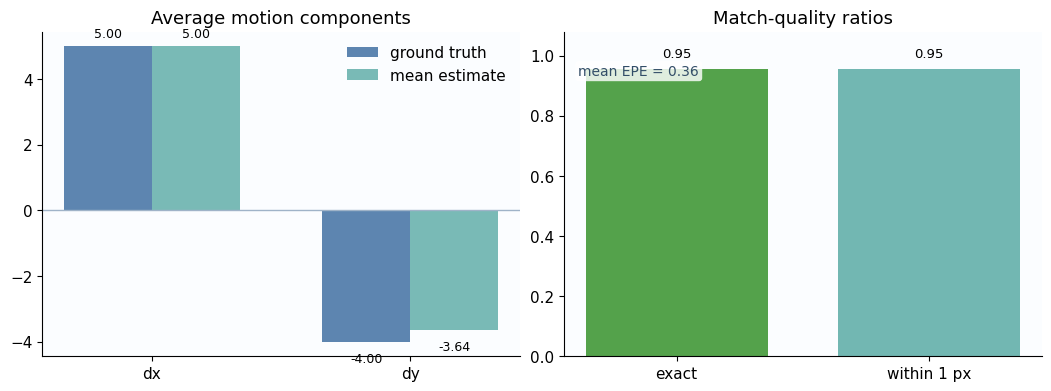

In [6]:
metric_names = ["mean_epe", "median_epe", "max_epe", "exact_match_ratio", "within_1px_ratio"]
for key in metric_names:
    print(f"{key:>20}: {summary[key]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.8), constrained_layout=True)
labels = ["dx", "dy"]
x = np.arange(len(labels))
width = 0.34
mean_estimate = np.array([
    np.mean([item["dx"] for item in estimates]),
    np.mean([item["dy"] for item in estimates]),
])

gt_bars = axes[0].bar(x - width / 2, gt_motion, width=width, color="#4c78a8", alpha=0.9, label="ground truth")
est_bars = axes[0].bar(x + width / 2, mean_estimate, width=width, color="#72b7b2", alpha=0.95, label="mean estimate")
axes[0].set_xticks(x, labels)
axes[0].set_title("Average motion components")
axes[0].legend(frameon=False, loc="upper right")
axes[0].axhline(0, color="#9fb3c8", linewidth=1.0)
for bars in [gt_bars, est_bars]:
    for bar in bars:
        height = bar.get_height()
        y_text = height + 0.18 if height >= 0 else height - 0.32
        va = "bottom" if height >= 0 else "top"
        axes[0].text(bar.get_x() + bar.get_width() / 2, y_text, f"{height:.2f}", ha="center", va=va, fontsize=9)

ratio_values = [summary["exact_match_ratio"], summary["within_1px_ratio"]]
ratio_labels = ["exact", "within 1 px"]
ratio_bars = axes[1].bar(ratio_labels, ratio_values, color=["#54a24b", "#72b7b2"], width=0.72)
axes[1].set_ylim(0, 1.08)
axes[1].set_title("Match-quality ratios")
axes[1].text(0.03, 0.90, f"mean EPE = {summary['mean_epe']:.2f}", transform=axes[1].transAxes,
             va="top", fontsize=10, color="#334e68",
             bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.82))
for bar, value in zip(ratio_bars, ratio_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.03, f"{value:.2f}",
                 ha="center", va="bottom", fontsize=9.5)
plt.show()


## Parameter sweeps / analysis

Three knobs matter immediately:

- **Patch size**: larger patches are often more stable, but they blur away local detail.
- **Search radius**: larger windows can recover larger motion, but they cost more and may invite distractors.
- **Noise level**: noisy images reduce the reliability of appearance matching.

![Parameter tradeoffs](assets/parameter-tradeoffs.svg)

The diagram above is only an overview. The sweep plots below are generated from deterministic synthetic pairs and a common set of valid tracking points so that the comparisons stay controlled.


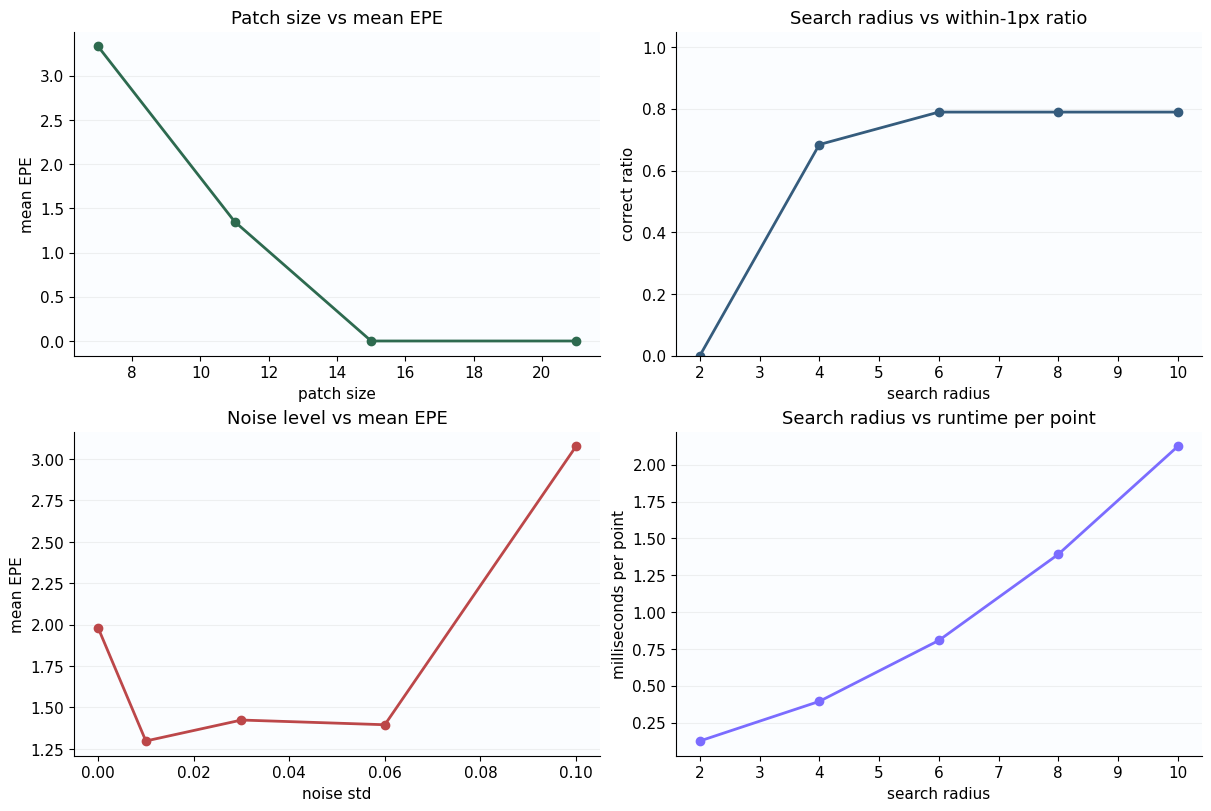

In [7]:
def evaluate_setting(dx=5, dy=-4, noise_std=0.015, patch_size=11, search_radius=8, seed=123):
    f1, f2, gt = make_synthetic_pair(dx=dx, dy=dy, noise_std=noise_std, seed=seed)
    base_points = sample_textured_points(f1, patch_size=11, stride=12, threshold=0.08)
    points = filter_trackable_points(base_points, f1.shape, patch_size=patch_size, search_radius=search_radius)
    start = time.perf_counter()
    est = estimate_sparse_motion(f1, f2, points, patch_size=patch_size, search_radius=search_radius)
    elapsed_ms = 1000.0 * (time.perf_counter() - start)
    summary = summarize_motion_metrics(est, gt)
    summary["ms_per_point"] = elapsed_ms / max(len(points), 1)
    summary["num_points"] = len(points)
    return summary


patch_sizes = [7, 11, 15, 21]
search_radii = [2, 4, 6, 8, 10]
noise_levels = [0.00, 0.01, 0.03, 0.06, 0.10]

patch_results = [evaluate_setting(patch_size=p, search_radius=8, noise_std=0.015, seed=321) for p in patch_sizes]
radius_results = [evaluate_setting(patch_size=11, search_radius=r, noise_std=0.015, seed=321) for r in search_radii]
noise_results = [evaluate_setting(patch_size=11, search_radius=8, noise_std=n, seed=321) for n in noise_levels]

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), constrained_layout=True)
axes = axes.ravel()

axes[0].plot(patch_sizes, [item["mean_epe"] for item in patch_results], marker="o", color="#2d6a4f", linewidth=2.0)
axes[0].set_title("Patch size vs mean EPE")
axes[0].set_xlabel("patch size")
axes[0].set_ylabel("mean EPE")

axes[1].plot(search_radii, [item["within_1px_ratio"] for item in radius_results], marker="o", color="#355c7d", linewidth=2.0)
axes[1].set_title("Search radius vs within-1px ratio")
axes[1].set_xlabel("search radius")
axes[1].set_ylabel("correct ratio")
axes[1].set_ylim(0, 1.05)

axes[2].plot(noise_levels, [item["mean_epe"] for item in noise_results], marker="o", color="#bc4749", linewidth=2.0)
axes[2].set_title("Noise level vs mean EPE")
axes[2].set_xlabel("noise std")
axes[2].set_ylabel("mean EPE")

axes[3].plot(search_radii, [item["ms_per_point"] for item in radius_results], marker="o", color="#7b6cff", linewidth=2.0)
axes[3].set_title("Search radius vs runtime per point")
axes[3].set_xlabel("search radius")
axes[3].set_ylabel("milliseconds per point")

for ax in axes:
    ax.grid(axis="y", alpha=0.18)

plt.show()


## Failure cases

A basic local matcher has clear blind spots. We will demonstrate two of the most important ones.

1. **Repetitive texture**: many candidate patches look equally good.
2. **Motion outside the search radius**: the correct answer is never even evaluated.

![Failure cases](assets/failure-cases.svg)

The executable failure panels below mark both the estimated target and the true target so the reason for failure is visually explicit.


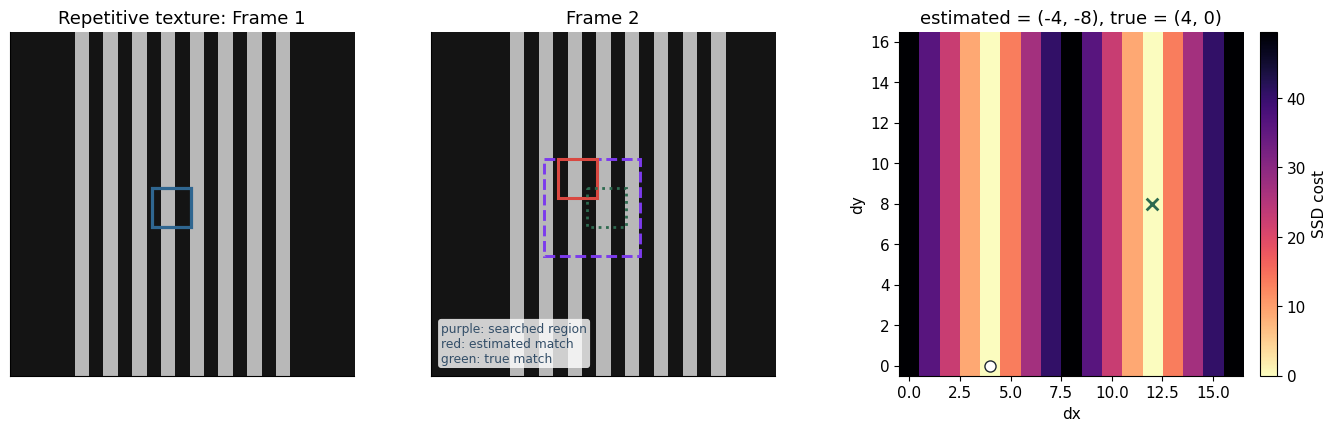

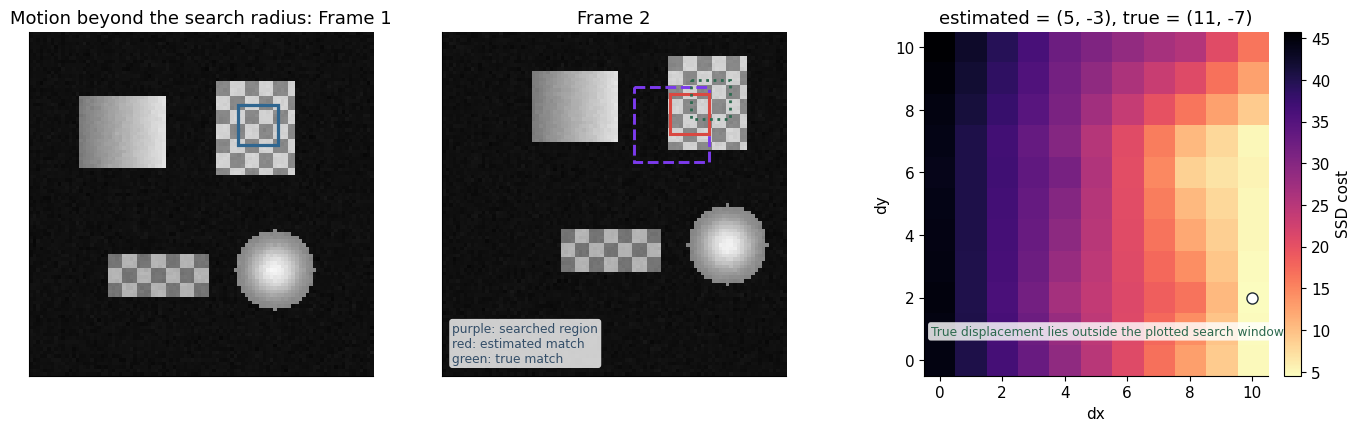

In [8]:
def make_repetitive_texture_pair(dx=4, dy=0, size=96):
    frame1 = np.full((size, size), 0.08, dtype=float)
    for x0 in range(18, 78, 8):
        frame1[:, x0 : x0 + 4] = 0.72
    frame2 = shift_image_integer(frame1, dx=dx, dy=dy, fill_value=0.08)
    return frame1, frame2, np.array([dx, dy], dtype=int)


def failure_demo(frame1, frame2, point_xy, gt_motion, patch_size, search_radius, title):
    gt_tuple = tuple(map(int, gt_motion))
    true_point = (point_xy[0] + gt_tuple[0], point_xy[1] + gt_tuple[1])
    result = estimate_patch_motion(frame1, frame2, point_xy, patch_size=patch_size, search_radius=search_radius)
    radius = patch_size // 2

    fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.2), constrained_layout=True)

    axes[0].imshow(frame1, cmap="gray", vmin=0, vmax=1, origin="upper")
    axes[0].add_patch(Rectangle((point_xy[0] - radius, point_xy[1] - radius), patch_size, patch_size,
                                edgecolor="#2f6690", facecolor="none", linewidth=2.3))
    axes[0].set_title(f"{title}: Frame 1")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(frame2, cmap="gray", vmin=0, vmax=1, origin="upper")
    axes[1].add_patch(Rectangle((point_xy[0] - search_radius - radius, point_xy[1] - search_radius - radius),
                                2 * search_radius + patch_size,
                                2 * search_radius + patch_size,
                                edgecolor="#7c3aed", facecolor="none", linewidth=2.1, linestyle="--"))
    axes[1].add_patch(Rectangle((result["best_point"][0] - radius, result["best_point"][1] - radius), patch_size, patch_size,
                                edgecolor="#d94841", facecolor="none", linewidth=2.2))
    axes[1].add_patch(Rectangle((true_point[0] - radius, true_point[1] - radius), patch_size, patch_size,
                                edgecolor="#2d6a4f", facecolor="none", linewidth=2.0, linestyle=":"))
    axes[1].text(0.03, 0.04, "purple: searched region\nred: estimated match\ngreen: true match",
                 transform=axes[1].transAxes, fontsize=8.8, color="#334e68",
                 bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.8))
    axes[1].set_title("Frame 2")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    im = axes[2].imshow(result["cost_map"], cmap="magma_r", origin="lower")
    est_x = result["dx"] + search_radius
    est_y = result["dy"] + search_radius
    axes[2].scatter(est_x, est_y, s=64, color="white", edgecolors="#1f2933", linewidths=1.0, zorder=4)
    if abs(gt_tuple[0]) <= search_radius and abs(gt_tuple[1]) <= search_radius:
        true_x = gt_tuple[0] + search_radius
        true_y = gt_tuple[1] + search_radius
        axes[2].scatter(true_x, true_y, s=72, marker="x", color="#2d6a4f", linewidths=2.0, zorder=4)
    else:
        axes[2].text(0.02, 0.11, "True displacement lies outside the plotted search window",
                     transform=axes[2].transAxes, ha="left", va="bottom", fontsize=8.8, color="#2d6a4f",
                     bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.82))
    axes[2].set_title(f"estimated = ({result['dx']}, {result['dy']}), true = {gt_tuple}")
    axes[2].set_xlabel("dx")
    axes[2].set_ylabel("dy")
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_label("SSD cost")
    plt.show()


repetitive_f1, repetitive_f2, repetitive_gt = make_repetitive_texture_pair(dx=4, dy=0)
failure_demo(repetitive_f1, repetitive_f2, point_xy=(44, 48), gt_motion=repetitive_gt,
             patch_size=11, search_radius=8, title="Repetitive texture")

large_f1, large_f2, large_gt = make_synthetic_pair(dx=11, dy=-7, noise_std=0.01, seed=11)
failure_demo(large_f1, large_f2, point_xy=(63, 25), gt_motion=large_gt,
             patch_size=11, search_radius=5, title="Motion beyond the search radius")


## Limitations and takeaway

Patch matching works well when:

- motion is moderate,
- the search window covers the true displacement,
- local texture is distinctive,
- and noise is not too strong.

It struggles when texture is ambiguous, motion is too large, illumination changes, or the underlying motion varies strongly inside one patch.
Those limitations are exactly why more advanced methods such as Lucas-Kanade, Horn-Schunck style optical flow, pyramidal search, and learned flow estimators exist.


## Reproducibility

- All random choices use a fixed seed.
- The main synthetic example uses integer translation so the ground truth is unambiguous.
- The notebook is organized so you can run it top to bottom without hidden state.

If you want an extra exercise, try replacing the global translation with rotation or locally varying motion and see where the baseline breaks first.
